In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv',skiprows=4,encoding='latin1')

In [3]:
df.head(3)

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,"Population, total",SP.POP.TOTL,54922.0,55578.0,56320.0,57002.0,57619.0,58190.0,...,108735.0,108908.0,109203.0,108587.0,107700.0,107310.0,107359.0,107995.0,NaN,NaN
1,Africa Eastern and Southern,AFE,"Population, total",SP.POP.TOTL,130075728.0,133534923.0,137171659.0,140945536.0,144904094.0,149033472.0,...,640058741.0,657801085.0,675950189.0,694446100.0,713090928.0,731821393.0,750491370.0,769280888.0,NaN,NaN
2,Afghanistan,AFG,"Population, total",SP.POP.TOTL,9035043.0,9214083.0,9404406.0,9604487.0,9814318.0,10036008.0,...,35688935.0,36743039.0,37856121.0,39068979.0,40000412.0,40578842.0,41454761.0,42647492.0,NaN,NaN


In [4]:
latest_year=df.columns[-3]

In [5]:
population=df[latest_year]

In [6]:
population=population.dropna()

In [7]:
# Log transform to fix skewness
log_population=np.log10(population)

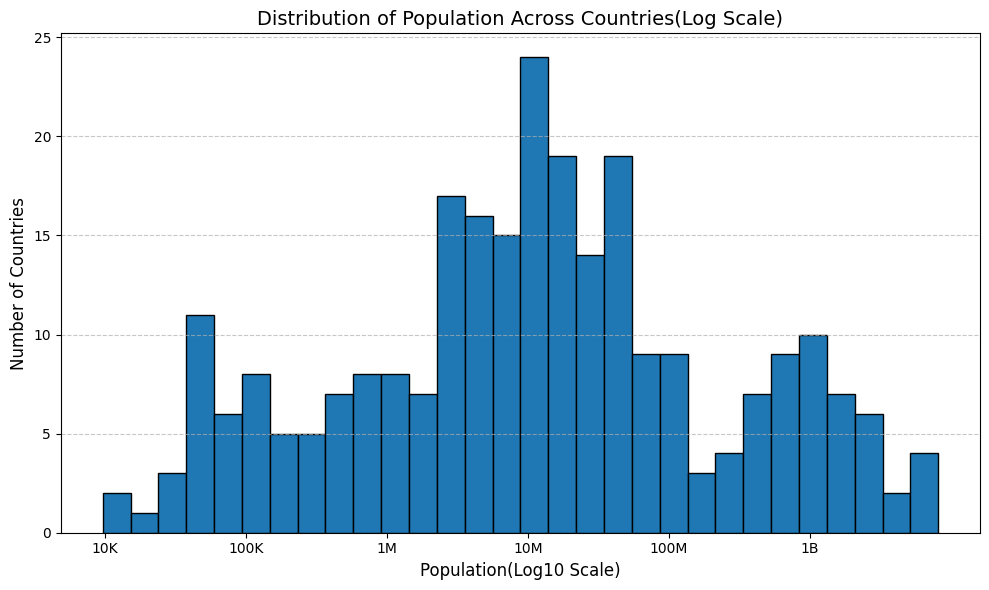

In [26]:
#Plot histogram
plt.figure(figsize=(10,6))
plt.hist(log_population,bins=30,edgecolor='black')
plt.title("Distribution of Population Across Countries(Log Scale)",fontsize=14)
plt.xlabel("Population(Log10 Scale)",fontsize=12)
plt.ylabel("Number of Countries",fontsize=12)
plt.xticks(
    ticks=[4,5,6,7,8,9],
    labels=['10K','100K','1M','10M','100M','1B']
)
plt.grid(axis='y',linestyle='--',alpha=0.7)
plt.tight_layout()
plt.savefig("histogram.png", dpi=300, bbox_inches='tight')
plt.show()

## Observation:
The histogram of the log-transformed population data shows a more uniform and interpretable distribution compared to the original skewed data. Most countries fall within the population range of 1 million to 100 million. A smaller number of countries have extremely high populations (close to or above 1 billion), while very few have extremely low populations. The log transformation effectively reduces skewness and spreads the data more evenly across bins, making patterns easier to analyze.

In [11]:
meta=pd.read_csv('Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_127039.csv')

In [13]:
meta.head(1)

,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN


In [17]:
# Keeps only real countries (Region not null)
real_countries=meta[meta['Region'].notnull()]

In [18]:
# Filtering main dataset using Country Code
df_countries=df[df['Country Code'].isin(real_countries['Country Code'])]

In [19]:
data=df_countries[['Country Name',latest_year]].dropna()

In [20]:
# Sort and take top 10 countries
top10=data.sort_values(by=latest_year,ascending=False).head(10)

In [21]:
top10

,Country Name,2024
109,India,1.450936e+09
40,China,1.408975e+09
251,United States,3.401110e+08
106,Indonesia,2.834879e+08
184,Pakistan,2.512692e+08
174,Nigeria,2.326795e+08
29,Brazil,2.119986e+08
20,Bangladesh,1.735624e+08
202,Russian Federation,1.435339e+08
72,Ethiopia,1.320598e+08


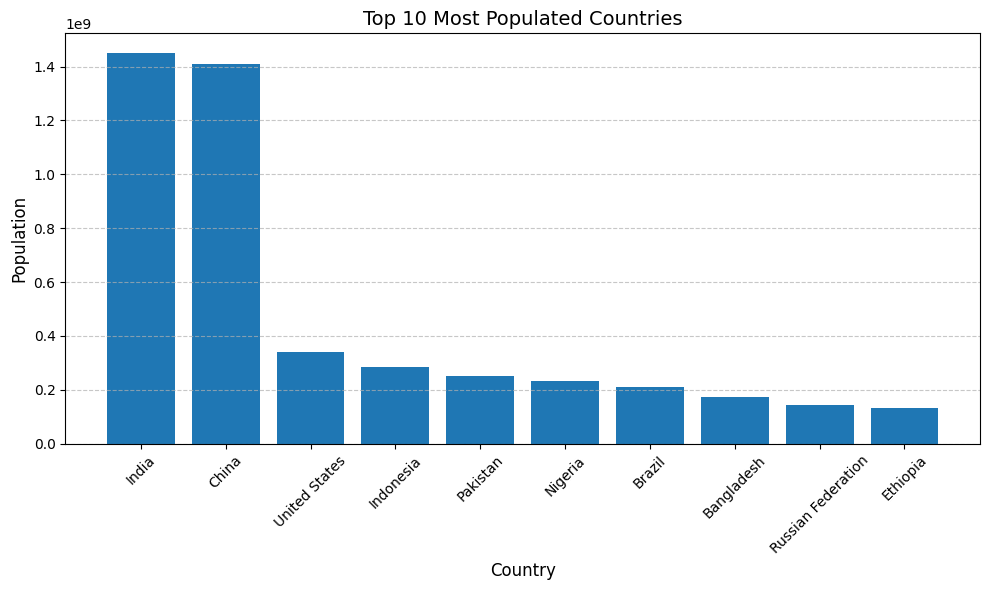

In [27]:
# Plot Bar Chart
plt.figure(figsize=(10,6))
plt.bar(top10['Country Name'],top10[latest_year])
plt.title("Top 10 Most Populated Countries", fontsize=14)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Population", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("bar.png", dpi=300, bbox_inches='tight')
plt.show()